In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from sklearn.svm import SVR

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [7]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [8]:
from sklearn.inspection import permutation_importance

In [9]:
from sklearn.model_selection import cross_val_score, LeaveOneOut, KFold

In [10]:
dataset = pd.read_excel('Dataset_QC.xlsx', sheet_name='Features', engine='openpyxl')
features = dataset.drop(columns=['Feature 115 Gordy\nEN      avarage','Feature 116 Gordy\nEN\nsum'])
features

,Composition,Feature 1 Atomic weight average,Feature 2 Atomic weight Sum,Feature 3 Atomic weight variance,Feature 4 Atomic weight max,Feature 5 Atomic weight mim,Feature 6 Atomic weight diference,Feature 7 Atomic \nnumber average,Feature 8 Atomic \nnumber sum,Feature 9 Atomic \nnumber variance,...,Feature 195 Cohesive \nenergy variance,Feature 196 Cohesive \nenergy max,Feature 197 Cohesive energy min,Feature 198 Cohesive \nenergy diference,Feature 199 Space group number,Feature 200 Crystal system,Feature 201 Density (g/cm^3),"Feature 202 Average anisotropy (average between a/b, b/c, c/a)",Feature 203 V per atom,Feature 204 Concentration 2
0,SrYAl3O7,30.788855,369.466257,1385.770366,88.90584,15.9994,72.90644,14.333333,172,255.44,...,2.225960,4.37,1.72,2.65,113,2,3.99,1.059960,307.74,0.006
1,La2Sr3B4O12,36.947990,775.907800,2901.809041,138.90550,10.8110,128.09450,16.380952,344,489.84,...,4.162184,5.81,1.72,4.09,33,3,4.78,1.201682,1077.54,0.033
2,Y4Al2O9,36.905403,553.581038,1081.881628,88.90584,15.9994,72.90644,16.933333,254,206.80,...,3.180904,4.37,2.62,1.75,14,6,4.44,1.050780,813.74,0.020
3,CaMoO4,33.337600,200.025600,1289.232663,95.95000,15.9994,79.95060,15.666667,94,249.60,...,6.262944,6.82,1.84,4.98,88,2,4.25,1.215049,312.31,0.050
4,Ba2SiO4,52.391014,366.737100,2664.285109,137.32700,15.9994,121.32760,22.571429,158,435.84,...,3.033360,4.63,1.90,2.73,62,3,5.47,1.073927,445.63,0.030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,CaLaAl3O7,30.993660,371.923917,2406.265165,138.90550,15.9994,122.90610,14.333333,172,392.24,...,2.273304,4.47,1.84,2.63,113,2,3.93,1.058188,314.32,0.060
118,GdSr2AlO5,48.829838,439.468539,3363.435706,157.25000,15.9994,141.25060,21.444444,193,549.44,...,2.055024,4.14,1.72,2.42,140,2,5.58,1.075668,523.56,0.040
119,LaVO4,42.307433,253.844600,2734.241415,138.90550,15.9994,122.90610,18.666667,112,458.64,...,4.857880,5.31,2.62,2.69,14,6,5.07,1.001617,332.83,0.010
120,Sr3Ga4O9,42.859162,685.746600,1357.004880,87.62000,15.9994,71.62060,19.375000,310,256.64,...,1.498880,2.81,1.72,1.09,2,7,6.49,1.035786,485.69,0.050


In [11]:
X = features.drop(columns=['Composition','Feature 204   Concentration 2 '])
Y = features['Feature 204   Concentration 2 ']

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [13]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
sns.set_style("ticks")
sns.set_context("paper")

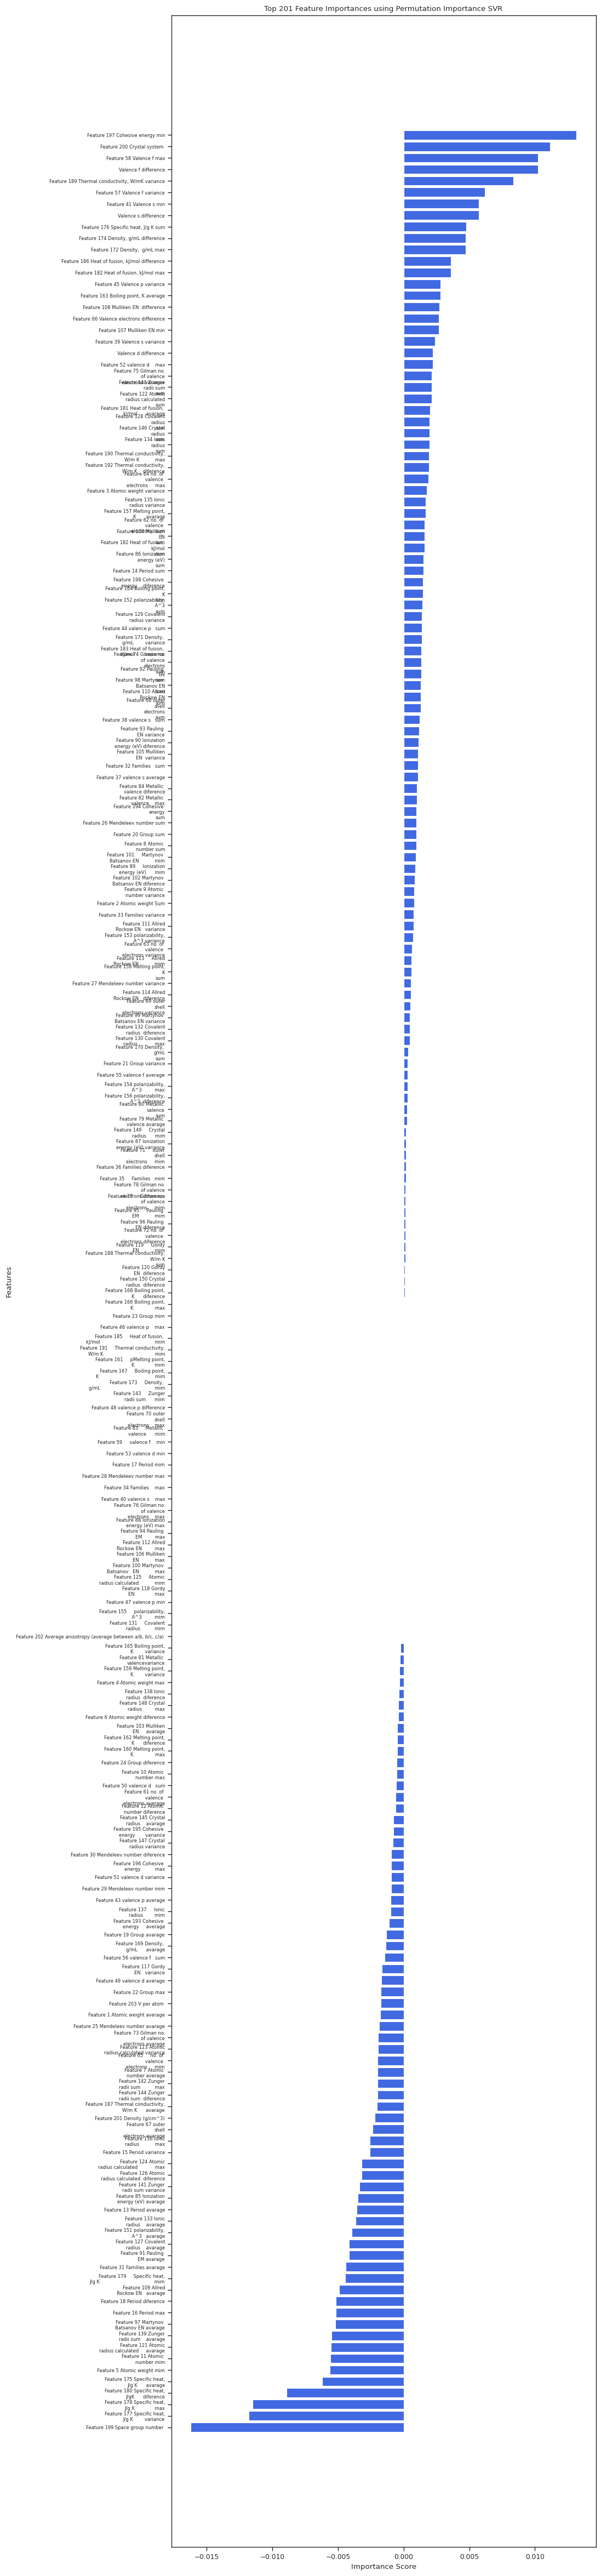

In [16]:
model = SVR(kernel='rbf',C=0.1,epsilon=0.001)
model.fit(X_train, Y_train)
result = permutation_importance(model, X_test, Y_test, n_repeats=10, random_state=42, scoring='r2')
importances = result.importances_mean
indices = np.argsort(importances)[::-1]
feature_names = features.drop(columns=['Composition', 'Feature 204   Concentration 2 '], axis=1).columns
N = len(importances)
top_indices = indices[:N]
top_importances = importances[top_indices]
top_features = np.array(feature_names)[top_indices]
plt.figure(figsize=(10, 60))
plt.barh(range(N), top_importances, align="center", color="royalblue")
plt.yticks(range(N), top_features, fontsize=6)
plt.savefig("feature_importance.pdf", bbox_inches="tight")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title(f"Top {N} Feature Importances using Permutation Importance SVR")
plt.gca().invert_yaxis()
plt.show()

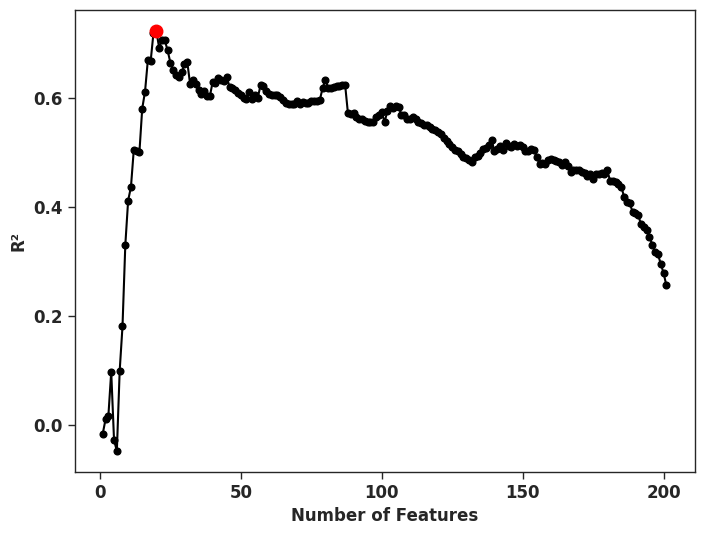

In [17]:
models_to_evaluate = {}

C_values = [1]
epsilon_values = [0.01]

for c in C_values:
  for epsilon in epsilon_values:
    model_name = f'SVR (C={c}, epsilon={epsilon})'
    models_to_evaluate[model_name] = SVR(kernel='rbf', C=c, epsilon=epsilon)

n_features_total = X_train.shape[1]

all_r2_scores = {}

for model_name, model_to_evaluate in models_to_evaluate.items():

    r2_scores = []

    for k in range(1, n_features_total + 1):
        top_k_indices = indices[:k]
        X_train_k = X_train[:, top_k_indices]
        X_test_k = X_test[:, top_k_indices]
        model_to_evaluate.fit(X_train_k, Y_train)
        y_pred_k = model_to_evaluate.predict(X_test_k)
        r2 = r2_score(Y_test, y_pred_k)
        r2_scores.append(r2)
    all_r2_scores[model_name] = r2_scores

plt.figure(figsize=(8, 6))
ax = plt.gca()

overall_min_r2 = min(min(scores) for scores in all_r2_scores.values())
overall_max_r2 = max(max(scores) for scores in all_r2_scores.values())

y_ticks = np.arange(0, overall_max_r2 , 0.2)

feature_counts = range(1, n_features_total + 1)

for model_name, r2_scores in all_r2_scores.items():
    plt.plot(feature_counts, r2_scores, marker='o', linewidth=1.5, label=model_name, color='black')

    max_r2_value = max(r2_scores)
    max_r2_index = r2_scores.index(max_r2_value)
    num_features_at_max = feature_counts[max_r2_index]

    plt.plot(num_features_at_max, max_r2_value, marker='o', markersize=9, color='red', label=f'Highest R²: {max_r2_value:.4f} ({num_features_at_max} features)')

plt.xticks(np.arange(0, n_features_total + 1, step=50))
plt.yticks(y_ticks)

plt.xlabel('Number of Features',fontweight='bold', fontsize=12)
plt.ylabel('R²', fontweight='bold', fontsize=12)

for label in ax.get_xticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(12)

for label in ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(12)

plt.grid(False)
plt.savefig("r².png", bbox_inches="tight", dpi=1200)
plt.show()

In [18]:
rf_model = SVR(kernel='rbf',C=0.1,epsilon=0.001)
rf_model.fit(X_train, Y_train)
result = permutation_importance(rf_model, X_test, Y_test, n_repeats=10, random_state=42, scoring='r2')
importances = result.importances_mean
indices = np.argsort(importances)[::-1]
feature_names = features.drop(columns=['Composition', 'Feature 204   Concentration 2 '], axis=1).columns
N = 20
top_indices = indices[:N]
top_importances = importances[top_indices]
top_features = np.array(feature_names)[top_indices]

In [19]:
selected_features = top_features.tolist() + ['Feature 204   Concentration 2 ']
feat_selected = features[selected_features]
feat_selected

,Feature 197 Cohesive energy min,Feature 200 Crystal system,Feature 58 Valence f max,Valence f difference,"Feature 189 Thermal conductivity, W/mK variance",Feature 57 Valence f variance,Feature 41 Valence s min,Valence s difference,"Feature 176 Specific heat, J/g K sum","Feature 174 Density, g/mL difference",...,"Feature 186 Heat of fusion, kJ/mol difference","Feature 182 Heat of fusion, kJ/mol max",Feature 45 Valence p variance,"Feature 163 Boiling point, K average",Feature 108 Mulliken EN difference,Feature 66 Valence electrons difference,Feature 107 Mulliken EN min,Feature 39 Valence s variance,Valence d difference,Feature 204 Concentration 2
0,1.72,2,0,0,8189.156816,0.00,2,0,9.740,4.46857,...,11.17741,11.40,2.40,1176.566667,5.54,4,2.00,0.64,1,0.006
1,1.72,3,0,0,201.480363,0.00,2,0,16.400,6.14857,...,49.97741,50.20,2.40,1457.502381,5.54,4,2.00,0.64,1,0.033
2,2.62,6,0,0,8707.718730,0.00,2,0,11.280,4.46857,...,11.17741,11.40,2.40,1382.150000,4.35,3,3.19,0.96,1,0.020
3,1.84,2,0,0,7238.317065,0.00,1,1,4.560,10.19857,...,31.77741,32.00,2.56,1167.150000,5.34,4,2.20,0.80,5,0.050
4,1.90,3,0,0,3340.597752,0.00,2,0,4.798,3.49857,...,50.32741,50.55,2.56,973.578571,5.14,4,2.40,0.96,0,0.030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,1.84,2,0,0,11151.276400,0.00,2,0,9.960,6.14857,...,10.56741,10.79,2.40,1194.650000,5.34,4,2.20,0.64,1,0.060
118,1.72,2,7,7,8303.588535,7.84,2,0,6.330,7.89857,...,10.56741,10.79,2.40,1116.816667,5.54,8,2.00,0.64,1,0.040
119,2.62,6,0,0,146.707962,0.00,2,0,4.360,6.14857,...,20.67741,20.90,2.56,1290.150000,4.44,3,3.10,0.96,3,0.010
120,1.72,7,0,0,348.295349,0.00,2,0,10.660,5.89857,...,8.07741,8.30,2.40,1030.462500,5.54,11,2.00,0.96,10,0.050


In [20]:
X2 = feat_selected.drop(columns=['Feature 204   Concentration 2 '])
Y2 = feat_selected['Feature 204   Concentration 2 ']

In [21]:
X2_train, X2_test, Y2_train, Y2_test = train_test_split(X2, Y2, test_size=0.2, random_state=42)

In [22]:
X2_train = X2_train[~Y2_train.isnull()]
Y2_train = Y2_train[~Y2_train.isnull()]
X2_test = X2_test[~Y2_test.isnull()]
Y2_test = Y2_test[~Y2_test.isnull()]
feature_names = X2.columns

In [23]:
scaler = MinMaxScaler()
X2_train = scaler.fit_transform(X2_train)
X2_test = scaler.transform(X2_test)

In [24]:
train_score = []
test_score = []
r2_test = []
C = [10,5,3,1,0.1,0.3,0.5]
epsilon = [1,0.1,0.01,0.001]
for x in C:
  for y in epsilon:
    model = SVR(kernel='rbf', C=x, epsilon=y)
    model.fit(X2_train, Y2_train)
    y_pred = model.predict(X2_test)
    train_score.append(model.score(X2_train, Y2_train))
    test_score.append(model.score(X2_test, Y2_test))
    r2_test.append(r2_score(Y2_test, y_pred))
    print(f'C: {x}, epsilon: {y}, test_score: {model.score(X2_test, Y2_test)}, train_score: {model.score(X2_train, Y2_train)}, r_2 : {r2_score(Y2_test, y_pred)}, MSE : {mean_squared_error(Y2_test, y_pred)}, MAE : {mean_absolute_error(Y2_test, y_pred)}')

C: 10, epsilon: 1, test_score: -2.5228862923766804, train_score: -2.091036643748841, r_2 : -2.5228862923766804, MSE : 0.02333800000000001, MAE : 0.14448
C: 10, epsilon: 0.1, test_score: -0.17325265389365851, train_score: 0.12762469011824795, r_2 : -0.17325265389365851, MSE : 0.007772425268400487, MAE : 0.07968414459835614
C: 10, epsilon: 0.01, test_score: 0.6092619643913915, train_score: 0.9641797888763995, r_2 : 0.6092619643913915, MSE : 0.0025885150749164936, MAE : 0.038133786229252016
C: 10, epsilon: 0.001, test_score: 0.5933173428128795, train_score: 0.9694099333403785, r_2 : 0.5933173428128795, MSE : 0.0026941431161066247, MAE : 0.04036376375431638
C: 5, epsilon: 1, test_score: -2.5228862923766804, train_score: -2.091036643748841, r_2 : -2.5228862923766804, MSE : 0.02333800000000001, MAE : 0.14448
C: 5, epsilon: 0.1, test_score: -0.17325265389365851, train_score: 0.12762469011824795, r_2 : -0.17325265389365851, MSE : 0.007772425268400487, MAE : 0.07968414459835614
C: 5, epsilon: 0

In [25]:
loo = LeaveOneOut()
model = SVR(kernel='rbf', C=1, epsilon=0.01)
model.fit(X2_train, Y2_train)
scores = cross_val_score(model, X2_test, Y2_test, cv=loo,scoring='neg_mean_squared_error')
print(scores)
print(np.mean(scores))

[-1.45861954e-03 -2.77655322e-03 -3.28840846e-03 -1.05884324e-03
 -9.36602495e-06 -4.44239055e-06 -5.91628141e-02 -1.26785263e-04
 -1.98627267e-04 -3.46497912e-03 -2.54013105e-04 -3.49248477e-03
 -6.86205242e-03 -8.05746388e-03 -4.89055021e-04 -9.05532373e-04
 -5.77571923e-03 -5.69694146e-04 -1.70321606e-03 -1.61537805e-03
 -3.41444351e-02 -1.80563202e-02 -4.81581008e-05 -4.49641154e-05
 -5.36088459e-05]
-0.006144861363019323


In [26]:
svr_rbf = regr = SVR(kernel='rbf',C=1,epsilon=0.01)
svr_rbf.fit(X2_train, Y2_train)
svr_rbf.score(X2_test, Y2_test), svr_rbf.score(X2_train, Y2_train)

(0.7221762355377651, 0.7539051309949664)

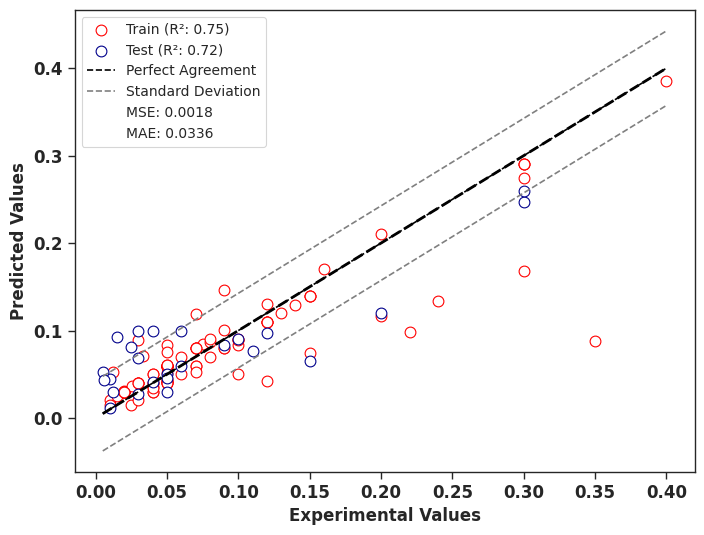

In [27]:
y_pred = svr_rbf.predict(X2_test)
y_pred_train = svr_rbf.predict(X2_train)
residuos = Y2_test - y_pred
residuo_std = np.std(residuos)
min_val = min(min(Y2_train), min(Y2_test))
max_val = max(max(Y2_train), max(Y2_test))
x = np.linspace(min_val, max_val, 100)
plt.figure(figsize=(8, 6))
ax = plt.gca()
plt.scatter(Y2_train, y_pred_train, facecolors='white', edgecolors='red', label='Train (R²: 0.75)', s=60)
plt.scatter(Y2_test, y_pred, facecolors='white', edgecolors='darkblue', label = 'Test (R²: 0.72)', s=60)
plt.plot(x, x, color='black', linestyle='--', label='Perfect Agreement')
plt.plot(x, x + residuo_std, color='grey', linestyle='--', label='Standard Deviation')
plt.plot(x, x - residuo_std, color='grey', linestyle='--')
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
plt.xlabel('Experimental Values', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=12, fontweight='bold')

mse = mean_squared_error(Y2_test, y_pred)
mae = mean_absolute_error(Y2_test, y_pred)
r2_svr = r2_score(Y2_test, y_pred)

from matplotlib.lines import Line2D
mse_label = f'MSE: {mse:.4f}'
mae_label = f'MAE: {mae:.4f}'

mse_line = Line2D([], [], color='none', label=mse_label)
mae_line = Line2D([], [], color='none', label=mae_label)

handles, labels = ax.get_legend_handles_labels()

handles.extend([mse_line, mae_line])
labels.extend([mse_label, mae_label])

ax.legend(handles=handles, labels=labels, fontsize=10)

for label in ax.get_xticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(12)

for label in ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(12)

plt.savefig("residuo.png", bbox_inches="tight", dpi=1400)
plt.show()

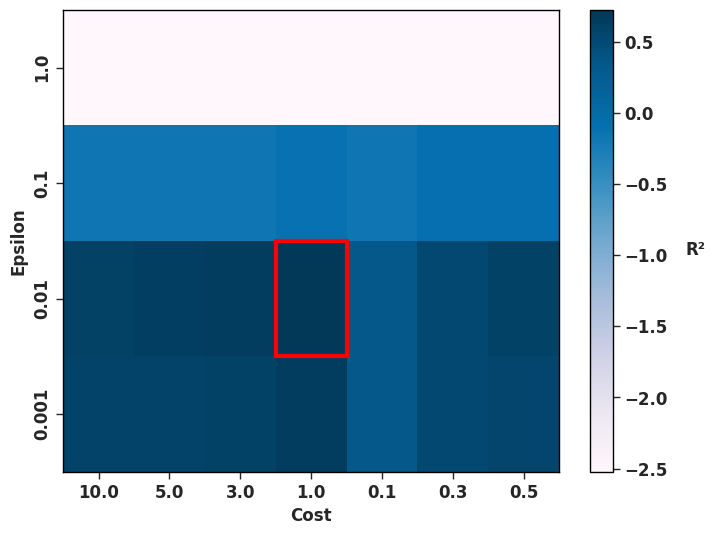

In [ ]:
C_values = np.array([10,5,3,1,0.1,0.3,0.5])
epsilon_values = np.array([1, 0.1, 0.01, 0.001])

test_score_grid = np.array(r2_test).reshape(len(C_values), len(epsilon_values)).T

plt.figure(figsize=(8, 6))
ax = sns.heatmap(test_score_grid,
                 annot=False,
                 fmt=".3f",
                 cmap="PuBu",
                 xticklabels=C_values,
                 yticklabels=epsilon_values,
                 cbar=False
                )

ax.set_xticklabels(C_values, fontsize=12, fontweight='bold')
ax.set_yticklabels(epsilon_values, fontsize=12, fontweight='bold')

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor('black')

cbar = ax.figure.colorbar(ax.collections[0], ax=ax, orientation='vertical', label='R²')
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(1)

cbar.set_label('R²', fontweight='bold', fontsize=12, labelpad=20, rotation=0)

for t in cbar.ax.get_yticklabels():
    t.set_fontweight('bold')
    t.set_fontsize(12)

ax.set_xlabel('Cost',  fontweight='bold', fontsize=12)
ax.set_ylabel('Epsilon', fontweight='bold', fontsize=12)

max_r2_index = np.unravel_index(np.argmax(test_score_grid, axis=None), test_score_grid.shape)

ax.add_patch(plt.Rectangle((max_r2_index[1], max_r2_index[0]), 1, 1, fill=False, edgecolor='red', lw=3))

plt.savefig("color_bar.png", bbox_inches="tight", dpi=1400)
plt.show()

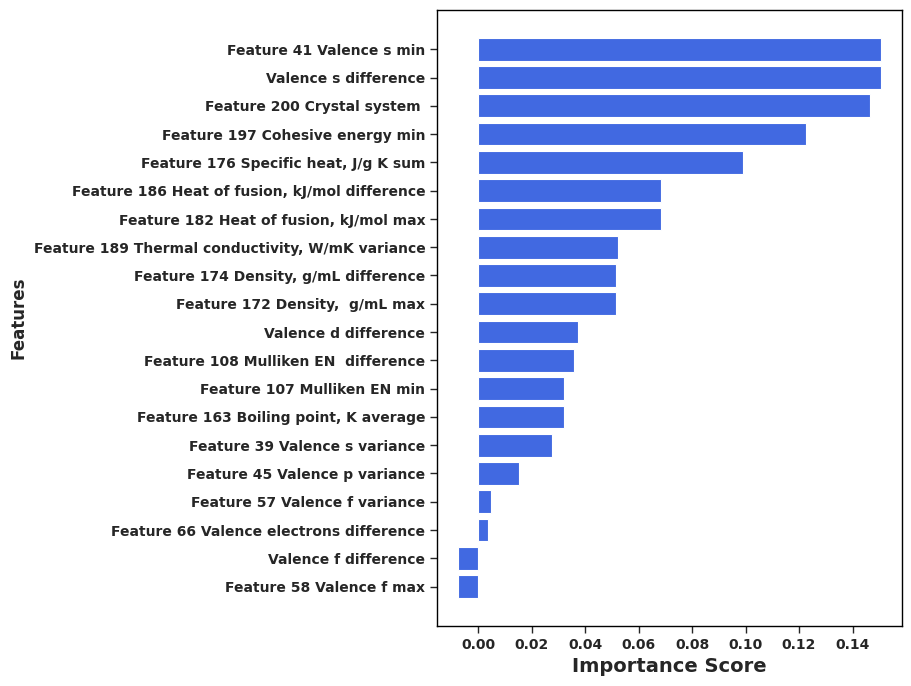

In [ ]:
svr = SVR(kernel='rbf', C=1, epsilon=0.01)
svr.fit(X2_train, Y2_train)
result = permutation_importance(svr, X2_test, Y2_test, n_repeats=10, random_state=42, scoring='r2')
importances = result.importances_mean
indices = np.argsort(importances)[::-1]
N = 20
top_indices = indices[:N]
top_importances = importances[top_indices]
top_features = np.array(X2.columns)[top_indices]

plt.figure(figsize=(6, 8))
ax = plt.gca()
plt.barh(range(N), top_importances, align="center", color="royalblue")
plt.yticks(range(N), top_features, fontsize=10, fontweight='bold')
plt.savefig("feature_importance.pdf", bbox_inches="tight")
plt.xlabel("Importance Score",fontweight='bold', fontsize=14)
plt.ylabel("Features", fontweight='bold', fontsize=12)
plt.gca().invert_yaxis()
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)
plt.grid(False)
plt.savefig("featu_importance.png", bbox_inches="tight", dpi=1400)

for label in ax.get_xticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(10)

plt.show()

In [ ]:
materials = pd.read_excel('Prevision_Materials.xlsx', sheet_name='Features', engine='openpyxl')
selected_features = ['Composition'] + [feature for feature in top3_features if feature in materials.columns] + ['Feature 204   Concentration 2 ']
materials_selected = materials[selected_features]
materials_selected


,Composition,Feature 197 Cohesive energy min,Feature 200 Crystal system,Feature 58 Valence f max,Valence f difference,"Feature 189 Thermal conductivity, W/mK variance",Feature 57 Valence f variance,Feature 41 Valence s min,Valence s difference,"Feature 176 Specific heat, J/g K sum",...,"Feature 186 Heat of fusion, kJ/mol difference","Feature 182 Heat of fusion, kJ/mol max",Feature 45 Valence p variance,"Feature 163 Boiling point, K average",Feature 108 Mulliken EN difference,Feature 66 Valence electrons difference,Feature 107 Mulliken EN min,Feature 39 Valence s variance,Valence d difference,Feature 204 Concentration 2
0,YVO4,2.62,2,0,0,155.787247,0.00,2,0,4.470,...,20.67741,20.90,2.56,1270.650000,4.35,3,3.19,0.96,3,NaN
1,Y3Al5O12,2.62,1,0,0,8707.718730,0.00,2,0,16.440,...,11.17741,11.40,2.40,1280.650000,4.35,3,3.19,0.96,1,NaN
2,LiSrPO4,1.63,5,0,0,1105.531744,0.00,1,1,8.350,...,8.07741,8.30,3.04,598.007143,5.54,5,2.00,0.64,0,NaN
3,YPO4,2.62,2,0,0,46.982693,0.00,2,0,4.750,...,11.17741,11.40,3.04,753.983333,4.35,3,3.19,0.96,1,NaN
4,LiBaPO4,1.63,6,0,0,1075.195216,0.00,1,1,8.254,...,7.52741,7.75,3.04,634.578571,5.14,5,2.40,0.64,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,Sr2Ta2O7,1.72,3,14,14,565.795997,31.36,2,0,7.320,...,31.37741,31.60,2.56,1394.695455,5.54,17,2.00,0.96,3,NaN
307,LaB3O6,2.62,6,0,0,116.553477,0.00,2,0,8.770,...,49.97741,50.20,2.40,1709.305000,4.44,3,3.10,0.96,1,NaN
308,CaMgB2O5,1.51,6,0,0,7144.620801,0.00,2,0,8.290,...,49.97741,50.20,2.40,1346.783333,5.34,4,2.20,0.64,0,NaN
309,CaMgB2O5,1.51,3,0,0,7144.620801,0.00,2,0,8.290,...,49.97741,50.20,2.40,1346.783333,5.34,4,2.20,0.64,0,NaN


In [ ]:
materials_selected = materials_selected.drop(columns=['Feature 204   Concentration 2 ','Composition'])

In [ ]:
materials_selected = scaler.transform(materials_selected)

In [ ]:
model = SVR(kernel='rbf', C=1, epsilon=0.01)
model.fit(X2_train, Y2_train)
model.score(X2_test, Y2_test)

0.7221762355377651

In [ ]:
for i in range(len(materials)):
    prediction = model.predict(materials_selected[[i]])
    material = materials['Composition'][i]
    print(f"{material} : {prediction[0]}")

YVO4 : 0.04483770095708891
Y3Al5O12 : 0.05962344625536913
LiSrPO4 : 0.10342100841955751
YPO4 : 0.025492539043074733
LiBaPO4 : 0.17392790189975538
LiBaPO4 : 0.11708070195306451
GdVO4 : 0.04351650237262052
Sc2Mo3O12 : 0.27741198622019
Bi4Ti3O12 : 0.10775240341427031
Bi4Ti3O12 : 0.09699077840454837
Bi4Ti3O12 : 0.13488070542463831
Lu3Al5O12 : 0.05911042594928035
Lu3Al2Ga3O12 : 0.05881303858089016
Zn2TiO4 : 0.02460821059427066
Zn2TiO4 : 0.025315672384892192
K3YB6O12 : 0.08359245189011306
Bi2Mo3O12 : 0.1509246673499896
Sr4Ca2W2O12 : 0.09834336332095187
Li2GeTeO6 : 0.1536472069703941
Li2GeTeO6 : 0.14281282495345549
LiGa5O8 : 0.08970281733279187
SrTiO3 : 0.021135478319187016
SrTiO3 : 0.02071248763471408
CaTiO3 : 0.05516884955506102
CaTiO3 : 0.06308047937706512
Al2BeO4 : 0.06521315133867436
Bi2Al4O9 : 0.07828446846117296
Bi2Ga4O9 : 0.10139467220917214
Al2O3 : 0.042475663846199135
Al2O3 : 0.05164948292310941
Al2O3 : 0.0651889834402502
GdAlO3 : 0.04631182162462996
GdAlO3 : 0.03233057586676686
LiA